# Linear Regression for Gold Price Forecasting

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score
)
import warnings
warnings.filterwarnings('ignore')

## 1. Load Data

In [40]:
# Load train/val/test data
X_train = pd.read_csv('../../../data/processed/splits/X_train.csv')
X_val   = pd.read_csv('../../../data/processed/splits/X_val.csv')
X_test  = pd.read_csv('../../../data/processed/splits/X_test.csv')

y_reg_train = pd.read_csv('../../../data/processed/splits/y_reg_train.csv').values.ravel()
y_reg_val   = pd.read_csv('../../../data/processed/splits/y_reg_val.csv').values.ravel()
y_reg_test  = pd.read_csv('../../../data/processed/splits/y_reg_test.csv').values.ravel()

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"\nTarget variable (% return tomorrow):")
print(f"  Train - Mean: {y_reg_train.mean():.6f}, Std: {y_reg_train.std():.6f}")
print(f"  Val   - Mean: {y_reg_val.mean():.6f}, Std: {y_reg_val.std():.6f}")
print(f"  Test  - Mean: {y_reg_test.mean():.6f}, Std: {y_reg_test.std():.6f}")

X_train shape: (1953, 20)
X_val shape:   (419, 20)
X_test shape:  (419, 20)

Target variable (% return tomorrow):
  Train - Mean: 0.023535, Std: 0.927849
  Val   - Mean: 0.079389, Std: 0.886621
  Test  - Mean: 0.162104, Std: 1.478886


## 2. Train Linear Regression Model

In [ ]:
# Train Linear Regression model
model = LinearRegression(n_jobs=-1)
model.fit(X_train, y_reg_train)

print("Model trained successfully!")
print(f"Number of features: {model.n_features_in_}")
print(f"Intercept: {model.intercept_:.6f}")

✓ Model trained successfully!
Number of features: 20
Intercept: 0.019884


## 3. Make Predictions

In [42]:
# Predictions on train, val, test sets
y_train_pred = model.predict(X_train)
y_val_pred   = model.predict(X_val)
y_test_pred  = model.predict(X_test)

print("Predictions shape:")
print(f"  y_train_pred: {y_train_pred.shape}")
print(f"  y_val_pred:   {y_val_pred.shape}")
print(f"  y_test_pred:  {y_test_pred.shape}")
print(f"\nPrediction ranges:")
print(f"  Train: [{y_train_pred.min():.6f}, {y_train_pred.max():.6f}]")
print(f"  Val:   [{y_val_pred.min():.6f}, {y_val_pred.max():.6f}]")
print(f"  Test:  [{y_test_pred.min():.6f}, {y_test_pred.max():.6f}]")

Predictions shape:
  y_train_pred: (1953,)
  y_val_pred:   (419,)
  y_test_pred:  (419,)

Prediction ranges:
  Train: [-2.150874, 1.940457]
  Val:   [-0.283251, 0.337155]
  Test:  [-0.632456, 0.940505]


## 4. Evaluation Metrics

In [43]:
def evaluate_regression(y_true, y_pred, set_name=""):
    """Compute and display regression evaluation metrics"""
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{set_name} Metrics:")
    print(f"  Mean Squared Error (MSE):  {mse:.8f}")
    print(f"  Root Mean Squared Error (RMSE): {rmse:.8f}")
    print(f"  Mean Absolute Error (MAE): {mae:.8f}")
    print(f"  R² Score:                  {r2:.6f}")
    
    return {'mse': mse, 'rmse': rmse, 'mae': mae, 'r2': r2}

# Evaluate on all sets
train_metrics = evaluate_regression(y_reg_train, y_train_pred, set_name="Train Set")
val_metrics   = evaluate_regression(y_reg_val, y_val_pred, set_name="Validation Set")
test_metrics  = evaluate_regression(y_reg_test, y_test_pred, set_name="Test Set")

# Create metrics summary
metrics_summary = pd.DataFrame({
    'Train': train_metrics,
    'Validation': val_metrics,
    'Test': test_metrics
})
print("\n" + "="*70)
print("Metrics Summary:")
print(metrics_summary)


Train Set Metrics:
  Mean Squared Error (MSE):  0.82994479
  Root Mean Squared Error (RMSE): 0.91101306
  Mean Absolute Error (MAE): 0.65714347
  R² Score:                  0.035961

Validation Set Metrics:
  Mean Squared Error (MSE):  0.79464187
  Root Mean Squared Error (RMSE): 0.89142687
  Mean Absolute Error (MAE): 0.66843179
  R² Score:                  -0.010870

Test Set Metrics:
  Mean Squared Error (MSE):  2.19744327
  Root Mean Squared Error (RMSE): 1.48237757
  Mean Absolute Error (MAE): 1.01541344
  R² Score:                  -0.004727

Metrics Summary:
         Train  Validation      Test
mse   0.829945    0.794642  2.197443
rmse  0.911013    0.891427  1.482378
mae   0.657143    0.668432  1.015413
r2    0.035961   -0.010870 -0.004727


## 5. Predicted vs Actual Values

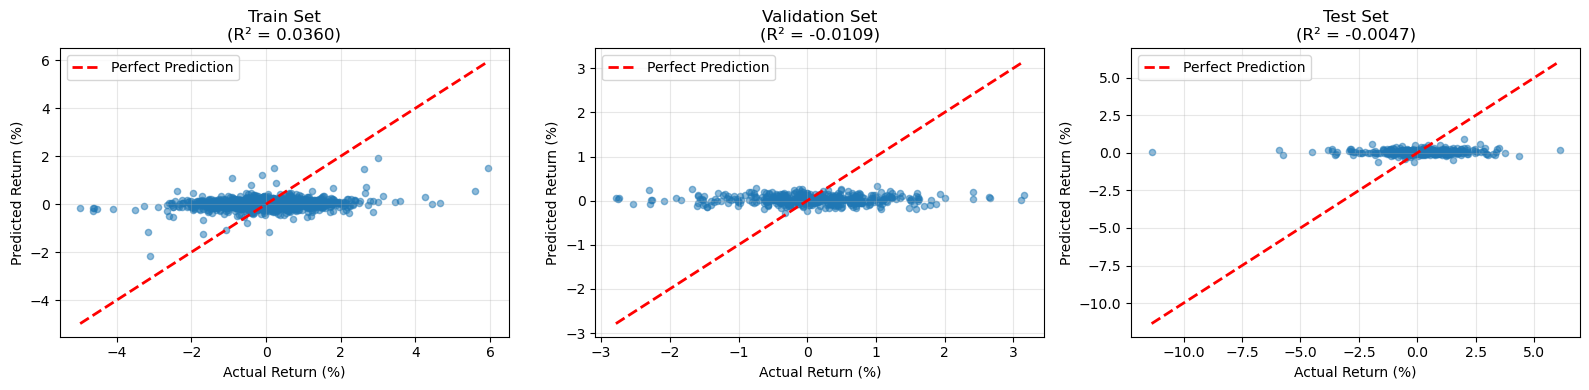

✓ Predictions plot saved


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot Predicted vs Actual for all sets
for idx, (y_true, y_pred, title) in enumerate([
    (y_reg_train, y_train_pred, 'Train Set'),
    (y_reg_val, y_val_pred, 'Validation Set'),
    (y_reg_test, y_test_pred, 'Test Set')
]):
    axes[idx].scatter(y_true, y_pred, alpha=0.5, s=20)
    
    # Add perfect prediction line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    axes[idx].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
    
    r2 = r2_score(y_true, y_pred)
    axes[idx].set_title(f'{title}\n(R² = {r2:.4f})')
    axes[idx].set_xlabel('Actual Return (%)')
    axes[idx].set_ylabel('Predicted Return (%)')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../../../outputs/linear_reg_predictions.png', dpi=150)
plt.show()

print("Predictions plot saved")

## 6. Residual Analysis

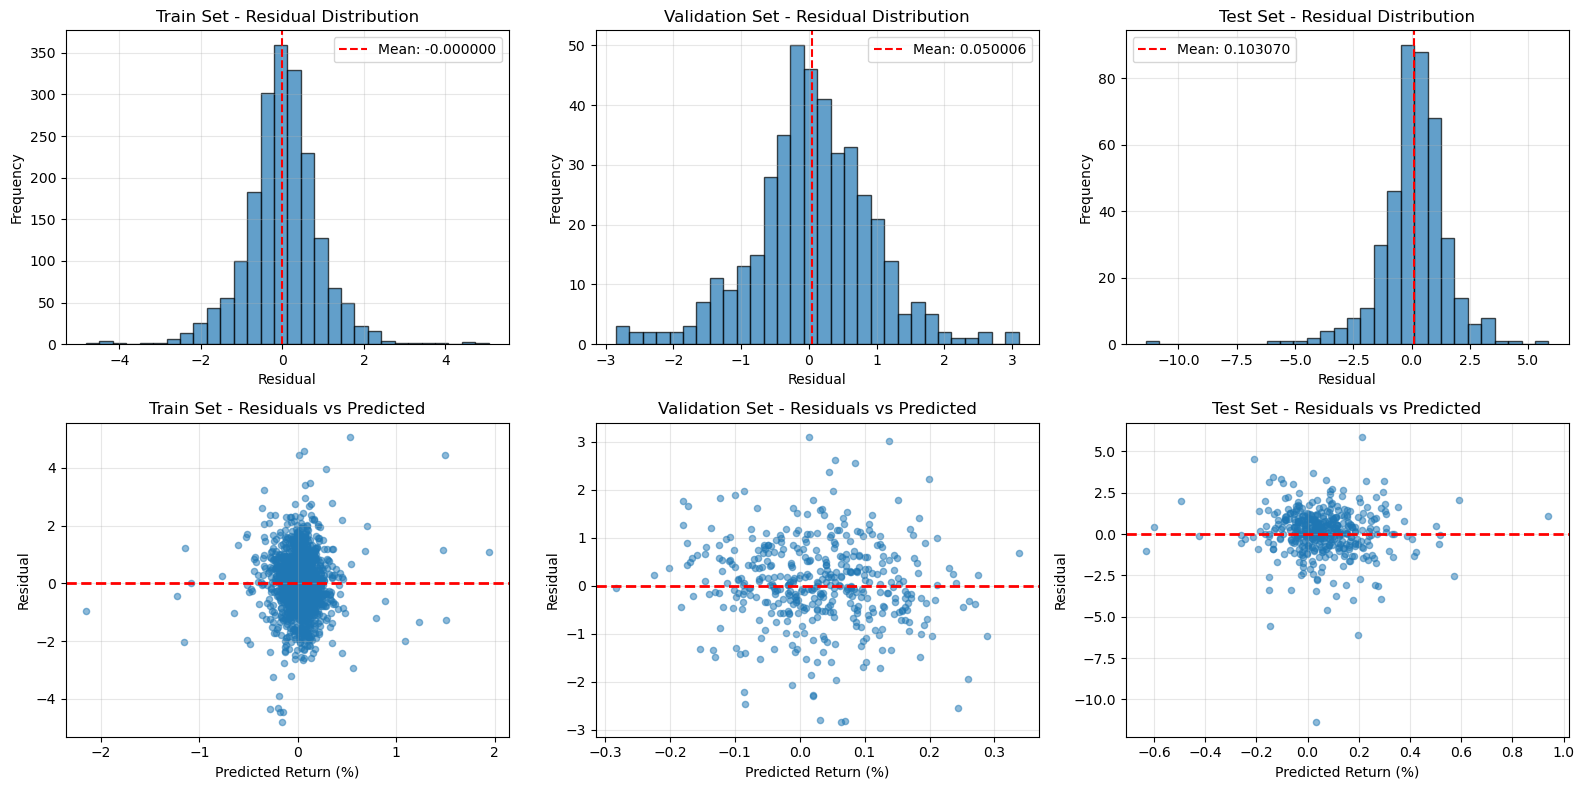

✓ Residual analysis plot saved


In [ ]:
# Calculate residuals
train_residuals = y_reg_train - y_train_pred
val_residuals   = y_reg_val - y_val_pred
test_residuals  = y_reg_test - y_test_pred

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# Residual distribution plots
for idx, (residuals, title) in enumerate([
    (train_residuals, 'Train Set'),
    (val_residuals, 'Validation Set'),
    (test_residuals, 'Test Set')
]):
    # Histogram
    axes[0, idx].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
    axes[0, idx].axvline(residuals.mean(), color='r', linestyle='--', label=f'Mean: {residuals.mean():.6f}')
    axes[0, idx].set_title(f'{title} - Residual Distribution')
    axes[0, idx].set_xlabel('Residual')
    axes[0, idx].set_ylabel('Frequency')
    axes[0, idx].legend()
    axes[0, idx].grid(True, alpha=0.3)
    
    # Residuals vs Predicted
    axes[1, idx].scatter(y_train_pred if idx == 0 else (y_val_pred if idx == 1 else y_test_pred), 
                         residuals, alpha=0.5, s=20)
    axes[1, idx].axhline(y=0, color='r', linestyle='--', lw=2)
    axes[1, idx].set_title(f'{title} - Residuals vs Predicted')
    axes[1, idx].set_xlabel('Predicted Return (%)')
    axes[1, idx].set_ylabel('Residual')
    axes[1, idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../../../outputs/linear_reg_residuals.png', dpi=150)
plt.show()

print("Residual analysis plot saved")

## 7. Feature Coefficients

Top 15 Features by Absolute Coefficient:
              feature  coefficient
  gold_close_pct_lag5    -0.057887
  dxy_close_pct_lag10    -0.044452
       gold_close_pct    -0.043419
 sp500_close_pct_lag5    -0.034858
      yield_close_pct    -0.034633
sp500_close_pct_lag10     0.028495
 yield_close_pct_lag5    -0.022029
 yield_close_pct_lag1    -0.015012
   dxy_close_pct_lag1     0.007803
        vix_close_pct    -0.007521
      sp500_close_pct    -0.007207
   vix_close_pct_lag5    -0.004601
   oil_close_pct_lag1    -0.004371
         gold_vol_log     0.003279
yield_close_pct_lag10     0.001600


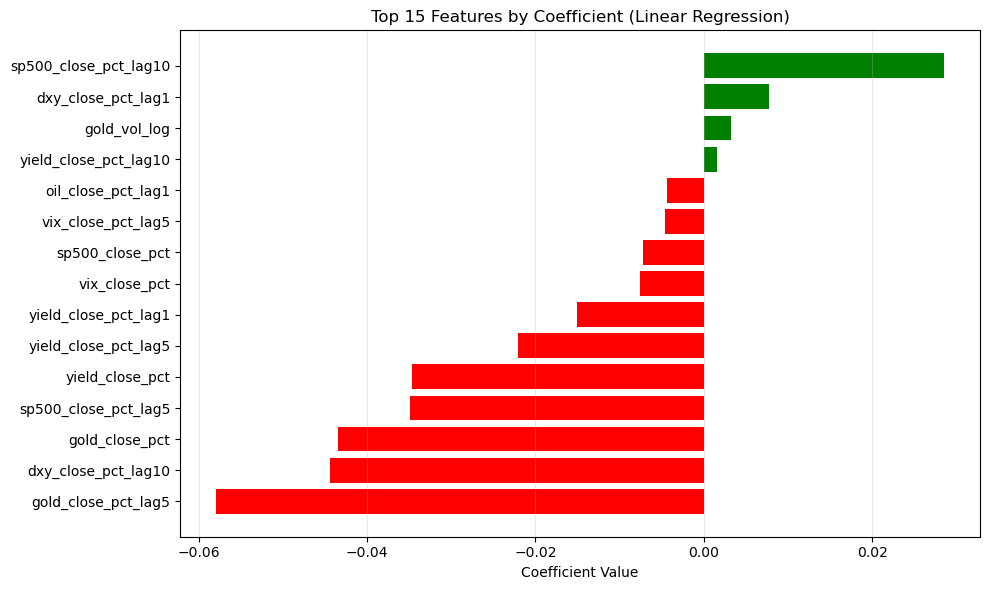

In [46]:
# Get feature coefficients
feature_names = X_train.columns.tolist()
coefficients = model.coef_

# Create a dataframe for better visualization
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
}).sort_values('coefficient', key=abs, ascending=False)

print("Top 15 Features by Absolute Coefficient:")
print(coef_df.head(15).to_string(index=False))

# Visualize top features
plt.figure(figsize=(10, 6))
top_features = coef_df.head(15).sort_values('coefficient')
colors = ['red' if x < 0 else 'green' for x in top_features['coefficient']]
plt.barh(top_features['feature'], top_features['coefficient'], color=colors)
plt.title('Top 15 Features by Coefficient (Linear Regression)')
plt.xlabel('Coefficient Value')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('../../../outputs/linear_reg_feature_coefficients.png', dpi=150)
plt.show()

## 8. Model Summary

In [47]:
print("="*70)
print("LINEAR REGRESSION MODEL SUMMARY")
print("="*70)
print(f"\nModel Configuration:")
print(f"  - Algorithm: Linear Regression (Ordinary Least Squares)")
print(f"  - Intercept: {model.intercept_:.8f}")
print(f"\nData Split:")
print(f"  - Training samples: {len(X_train)}")
print(f"  - Validation samples: {len(X_val)}")
print(f"  - Test samples: {len(X_test)}")
print(f"  - Total features: {len(feature_names)}")
print(f"\nTest Set Performance:")
print(f"  - R² Score: {test_metrics['r2']:.6f}")
print(f"  - RMSE:     {test_metrics['rmse']:.8f}")
print(f"  - MAE:      {test_metrics['mae']:.8f}")
print(f"  - MSE:      {test_metrics['mse']:.8f}")
print(f"\nKey Features (Top 5 by absolute coefficient):")
for i, row in coef_df.head(5).iterrows():
    print(f"  {row['feature']:>30}: {row['coefficient']:>12.8f}")
print(f"\nResidual Statistics (Test Set):")
print(f"  - Mean: {test_residuals.mean():.8f}")
print(f"  - Std:  {test_residuals.std():.8f}")
print(f"  - Min:  {test_residuals.min():.8f}")
print(f"  - Max:  {test_residuals.max():.8f}")
print("\n" + "="*70)

LINEAR REGRESSION MODEL SUMMARY

Model Configuration:
  - Algorithm: Linear Regression (Ordinary Least Squares)
  - Intercept: 0.01988443

Data Split:
  - Training samples: 1953
  - Validation samples: 419
  - Test samples: 419
  - Total features: 20

Test Set Performance:
  - R² Score: -0.004727
  - RMSE:     1.48237757
  - MAE:      1.01541344
  - MSE:      2.19744327

Key Features (Top 5 by absolute coefficient):
             gold_close_pct_lag5:  -0.05788723
             dxy_close_pct_lag10:  -0.04445156
                  gold_close_pct:  -0.04341925
            sp500_close_pct_lag5:  -0.03485825
                 yield_close_pct:  -0.03463270

Residual Statistics (Test Set):
  - Mean: 0.10307003
  - Std:  1.47878999
  - Min:  -11.39936805
  - Max:  5.87030144



## 9. Model Evaluation Summary

In [55]:
print("\n" + "="*70)
print("FINAL MODEL: RIDGE REGRESSION WITH FEATURE SCALING")
print("="*70)

# ==================== 1. FEATURE SCALING ====================
print("\n1. Feature Scaling (StandardScaler)")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
print("Features scaled successfully")

# ==================== 2. RIDGE REGRESSION WITH TUNING ====================
print("\n2. Ridge Regression (L2 Regularization) - Optimized Hyperparameters")
ridge_params = {
    'alpha': np.logspace(-6, 6, 25)  # Comprehensive alpha search
}
ridge_grid = GridSearchCV(
    Ridge(),
    ridge_params,
    cv=15,
    scoring='r2',
    n_jobs=-1
)
ridge_grid.fit(X_train_scaled, y_reg_train)
best_model = ridge_grid.best_estimator_

print(f"  Best alpha (regularization strength): {ridge_grid.best_params_['alpha']:.8f}")
print(f"  Best Cross-Validation R²: {ridge_grid.best_score_:.6f}")

# ==================== 3. PREDICTIONS ====================
print("\n3. Making Predictions on Test Set")
y_train_pred = best_model.predict(X_train_scaled)
y_val_pred = best_model.predict(X_val_scaled)
y_test_pred = best_model.predict(X_test_scaled)

# ==================== 4. EVALUATION ====================
print("\n4. Model Performance")
train_r2 = r2_score(y_reg_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_reg_train, y_train_pred))
train_mae = mean_absolute_error(y_reg_train, y_train_pred)

val_r2 = r2_score(y_reg_val, y_val_pred)
val_rmse = np.sqrt(mean_squared_error(y_reg_val, y_val_pred))
val_mae = mean_absolute_error(y_reg_val, y_val_pred)

test_r2 = r2_score(y_reg_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_reg_test, y_test_pred))
test_mae = mean_absolute_error(y_reg_test, y_test_pred)

print(f"\n  Training Set:")
print(f"    R² Score:  {train_r2:.6f}")
print(f"    RMSE:      {train_rmse:.8f}")
print(f"    MAE:       {train_mae:.8f}")

print(f"\n  Validation Set:")
print(f"    R² Score:  {val_r2:.6f}")
print(f"    RMSE:      {val_rmse:.8f}")
print(f"    MAE:       {val_mae:.8f}")

print(f"\n  Test Set:")
print(f"    R² Score:  {test_r2:.6f}")
print(f"    RMSE:      {test_rmse:.8f}")
print(f"    MAE:       {test_mae:.8f}")

# ==================== 5. METRICS SUMMARY TABLE ====================
print("\n" + "="*70)
print("METRICS SUMMARY:")
metrics_df = pd.DataFrame({
    'Metric': ['R² Score', 'RMSE', 'MAE'],
    'Train': [train_r2, train_rmse, train_mae],
    'Validation': [val_r2, val_rmse, val_mae],
    'Test': [test_r2, test_rmse, test_mae]
})
print(metrics_df.to_string(index=False))
print("="*70)



FINAL MODEL: RIDGE REGRESSION WITH FEATURE SCALING

1. Feature Scaling (StandardScaler)
Features scaled successfully

2. Ridge Regression (L2 Regularization) - Optimized Hyperparameters
  Best alpha (regularization strength): 3162.27766017
  Best Cross-Validation R²: -0.004905

3. Making Predictions on Test Set

4. Model Performance

  Training Set:
    R² Score:  0.020922
    RMSE:      0.91809125
    MAE:       0.65527180

  Validation Set:
    R² Score:  -0.003558
    RMSE:      0.88819674
    MAE:       0.66425510

  Test Set:
    R² Score:  -0.004175
    RMSE:      1.48196982
    MAE:       1.02148355

METRICS SUMMARY:
  Metric    Train  Validation      Test
R² Score 0.020922   -0.003558 -0.004175
    RMSE 0.918091    0.888197  1.481970
     MAE 0.655272    0.664255  1.021484
